# Tutorial 03d: Variational Autoencoders

Prof Ivan Olier

## Introduction

In the previous tutorial, we built a convolutional autoencoder: an encoder compressed each image into a deterministic bottleneck, and a decoder reconstructed the image from that bottleneck. A Variational Autoencoder (VAE) keeps the same encoder-decoder idea, but changes the bottleneck into a probabilistic latent space.

Instead of producing a single latent vector, the encoder learns two vectors for each input image: a mean, ($\mu$), and a log-variance, ($\log \sigma^2$). A latent vector ($z$) is then sampled from the corresponding distribution and passed to the decoder. This regularised latent space allows us not only to reconstruct images, but also to generate new images by sampling new latent vectors.

By the end of this tutorial, you should be able to:

- explain the difference between a standard autoencoder and a VAE;
- implement the reparameterisation trick;
- train a convolutional VAE on MNIST images;
- visualise the learned latent space; and
- generate new data from randomly sampled latent vectors.


We begin with the standard numerical and plotting libraries. The plots are particularly important in this tutorial because we want to inspect both reconstructions and newly generated images.


In [43]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline


The VAE will be implemented using TensorFlow/Keras. We use the Functional API for the encoder and decoder, and then wrap them inside a custom `Model` class so that we can train with the two-part VAE loss.


In [44]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.backend import clear_session
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, Conv2DTranspose, Flatten, Reshape, Lambda
)


For reproducibility, we set random seeds. This does not make every run exactly identical on every machine, but it reduces unnecessary variation during teaching demonstrations.


In [45]:
np.random.seed(42)
tf.random.set_seed(42)


The first helper function plots the losses recorded during training. A VAE has three relevant curves: the total loss, the reconstruction loss, and the KL regularisation term.


In [46]:
def plot_vae_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='total loss')
    plt.plot(history.history['reconstruction_loss'], label='reconstruction loss')
    plt.plot(history.history['kl_loss'], label='KL loss')

    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], linestyle='--', label='validation total loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


As in the convolutional autoencoder tutorial, visual comparison is the most intuitive way to assess reconstruction quality. The first row shows original images, and the second row shows their VAE reconstructions.


In [47]:
def plot_digits(X_true, X_pred, n=10):
    plt.figure(figsize=(20, 4))
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(X_true[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(X_pred[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()


The next helper function is used for generated images. Unlike reconstruction, there is no original image to compare with: the decoder receives latent vectors sampled directly from the latent distribution.


In [48]:
def plot_generated_images(images, n=16):
    rows = int(np.sqrt(n))
    cols = int(np.ceil(n / rows))
    plt.figure(figsize=(cols * 2, rows * 2))

    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.tight_layout()
    plt.show()


## Loading and preparing the MNIST data

We use MNIST again so that the focus remains on the modelling idea rather than on a new dataset. The images are reshaped into tensors of size \(28 \times 28 \times 1\), which is the expected input format for convolutional layers.


In [49]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

print('Training data shape:', X_train.shape)
print('Test data shape:', X_test.shape)


Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


The pixel values are converted to floating point numbers and scaled to the range \([0, 1]\). This matches the sigmoid activation that we will use in the decoder output layer.


In [50]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


To make the tutorial practical on CPU-only machines, we use a subset of the full training data. The numbers below can be increased if students are using a GPU or if more training time is available.


In [51]:
n_train = 20000
n_val = 5000

X_val = X_train[n_train:n_train + n_val]
X_train_small = X_train[:n_train]

print('Training subset:', X_train_small.shape)
print('Validation subset:', X_val.shape)


Training subset: (20000, 28, 28, 1)
Validation subset: (5000, 28, 28, 1)


## The reparameterisation trick

Sampling is not directly differentiable. If we sampled \(z\) naively from \(\mathcal{N}(\mu, \sigma^2)\), backpropagation would not pass cleanly through the sampling operation.

The reparameterisation trick solves this by sampling random noise \(\epsilon\) from a standard normal distribution and then transforming it:

\[
z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
\]

This keeps the randomness in \(\epsilon\), while \(\mu\) and \(\sigma\) remain differentiable network outputs.


In [52]:
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


## Building the encoder

The encoder is similar to the first half of a convolutional autoencoder, but the bottleneck is different. Instead of producing one encoded vector, it produces `z_mean` and `z_log_var`. These define the latent distribution for each input image.


In [53]:
clear_session()

latent_dim = 2

encoder_inputs = Input(shape=(28, 28, 1), name='encoder_input')
x = Conv2D(32, (3, 3), activation='relu', strides=2, padding='same')(encoder_inputs)
x = Conv2D(64, (3, 3), activation='relu', strides=2, padding='same')(x)
x = Flatten()(x)
x = Dense(32, activation='relu')(x)

z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)
z = Lambda(sampling, name='z')([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │    100,384 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         66 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         66 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 119,332 (466.14 KB)

 Trainable params: 119,332 (466.14 KB)

 Non-trainable params: 0 (0.00 B)

## Building the decoder

The decoder receives a sampled latent vector and maps it back to image space. The dense layer expands the latent vector to a small spatial feature map, and the transposed convolutions progressively increase the image size back to \(28 \times 28\).


In [54]:
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
x = Dense(7 * 7 * 64, activation='relu')(latent_inputs)
x = Reshape((7, 7, 64))(x)
x = Conv2DTranspose(64, (3, 3), activation='relu', strides=2, padding='same')(x)
x = Conv2DTranspose(32, (3, 3), activation='relu', strides=2, padding='same')(x)
decoder_outputs = Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, decoder_outputs, name='decoder')
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

## Defining the VAE loss

A VAE is trained with two objectives at the same time.

The reconstruction loss asks the model to reproduce the input image. The KL term regularises the latent distribution by pushing it towards a standard normal distribution, \(\mathcal{N}(0, I)\). This is what makes the latent space smoother and easier to sample from.

The total loss is:

\[
\mathcal{L} = \mathcal{L}_{reconstruction} + D_{KL}(q(z|x) \parallel p(z))
\]


In [55]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = tf.keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        _, _, z = self.encoder(inputs)
        return self.decoder(z)

    def _compute_losses(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.keras.losses.binary_crossentropy(data, reconstruction)
        reconstruction_loss = tf.reduce_sum(reconstruction_loss, axis=(1, 2))
        reconstruction_loss = tf.reduce_mean(reconstruction_loss)

        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1
        )
        kl_loss = tf.reduce_mean(kl_loss)

        total_loss = reconstruction_loss + kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_losses(data)

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            'loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, reconstruction_loss, kl_loss = self._compute_losses(data)

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            'loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result(),
        }


We can now create and compile the VAE. Notice that we do not pass a conventional loss function to `compile`, because the custom training step computes the reconstruction and KL losses internally.


In [56]:
vae = VAE(encoder, decoder, name='vae')
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))


The model is trained as an unsupervised reconstruction model, so the input images are also the learning signal. The validation data allows us to check whether the training behaviour is stable on images not used to update the weights.


In [57]:
history = vae.fit(
    X_train_small,
    epochs=500,
    batch_size=128,
    validation_data=(X_val,),
    verbose=1
)


Epoch 1/500


I0000 00:00:1782346157.618534   52356 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_151622__.15


155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - kl_loss: 1.3536 - loss: 339.6904 - reconstruction_loss: 338.3369

I0000 00:00:1782346160.533666   52356 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_151622__.15


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - kl_loss: 1.3552 - loss: 338.6132 - reconstruction_loss: 337.2580

I0000 00:00:1782346162.409439   52358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152820__.6
I0000 00:00:1782346163.370575   52360 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152820__.6


157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - kl_loss: 1.4898 - loss: 254.9564 - reconstruction_loss: 253.4665 - val_kl_loss: 2.9960 - val_loss: 201.5320 - val_reconstruction_loss: 198.5361
Epoch 2/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.0693 - loss: 195.8001 - reconstruction_loss: 192.7309 - val_kl_loss: 2.8399 - val_loss: 192.4315 - val_reconstruction_loss: 189.5916
Epoch 3/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 4.1708 - loss: 181.2101 - reconstruction_loss: 177.0393 - val_kl_loss: 4.3037 - val_loss: 177.2153 - val_reconstruction_loss: 172.9116
Epoch 4/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - kl_loss: 4.4851 - loss: 173.3418 - reconstruction_loss: 168.8567 - val_kl_loss: 4.5753 - val_loss: 170.6832 - val_reconstruction_loss: 166.1079
Epoch 5/500
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 4.7603 - loss: 168.2190 - reconstruction_loss: 163.4587 - val_kl_loss: 4.8734 - val_loss: 167.1479 - val_reconstruction_loss: 162.2745
Epoch 6/500
157/

The loss curves help us see the trade-off between reconstruction quality and latent-space regularisation. The reconstruction loss usually dominates numerically, while the KL term controls how much structure is imposed on the latent space.


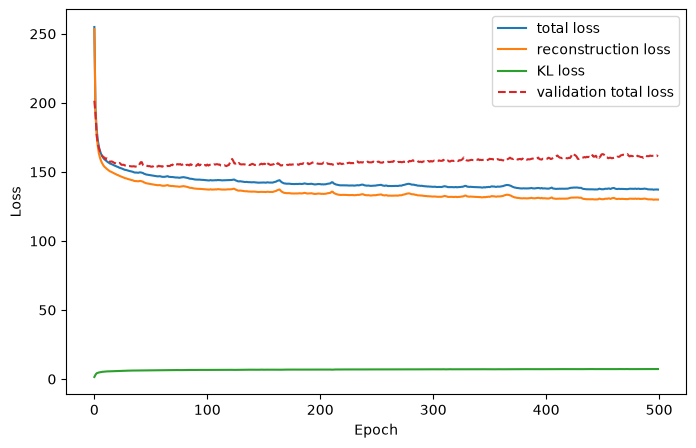

In [58]:
plot_vae_history(history)


## Reconstructing test images

The first check is whether the VAE can reconstruct images that were not used during training. VAEs often produce slightly smoother images than deterministic autoencoders because the latent representation is regularised rather than free to store arbitrary detail.


I0000 00:00:1782346637.598120   52358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_661720__.1


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step


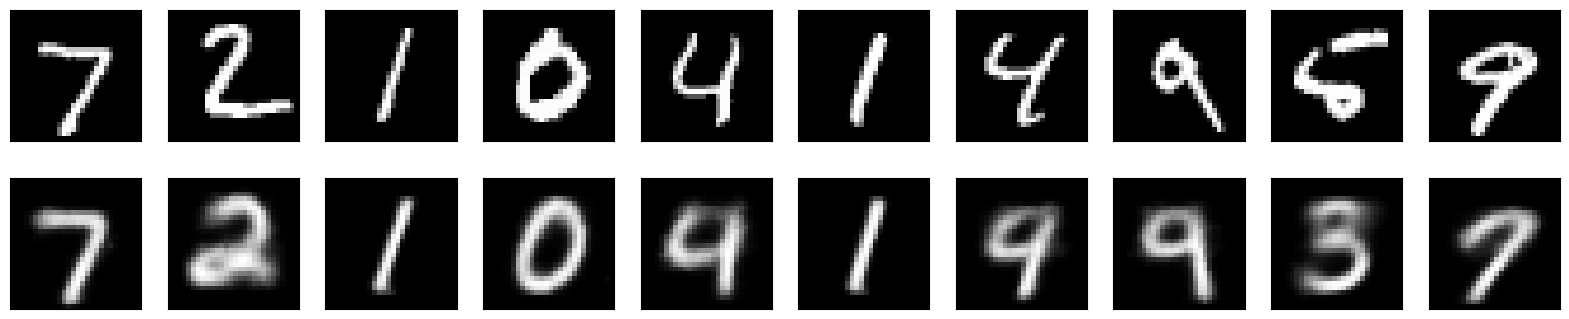

In [59]:
X_pred = vae.predict(X_test[:10])
plot_digits(X_test[:10], X_pred[:10], n=10)


## Visualising the latent space

Because we used a two-dimensional latent space, we can plot the encoded test images directly. Each point below represents one image, positioned according to its latent mean, \(\mu\). The colours correspond to the true digit labels, which are used only for visualisation.


I0000 00:00:1782346638.481939   52360 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_661873__.1


59/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

I0000 00:00:1782346639.151474   52354 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_662278__.1


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


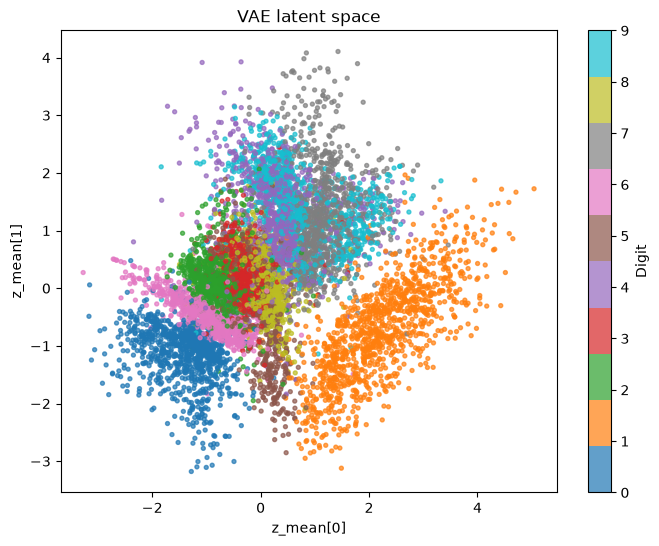

In [60]:
z_mean_test, z_log_var_test, z_test = encoder.predict(X_test, batch_size=128)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap='tab10',
    s=8,
    alpha=0.7
)
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.xlabel('z_mean[0]')
plt.ylabel('z_mean[1]')
plt.title('VAE latent space')
plt.show()


The next plot compares the two learned latent dimensions against the target standard normal distribution. The latent space will not be perfect, especially after a short classroom training run, but the KL term encourages the values to remain centred and reasonably compact.


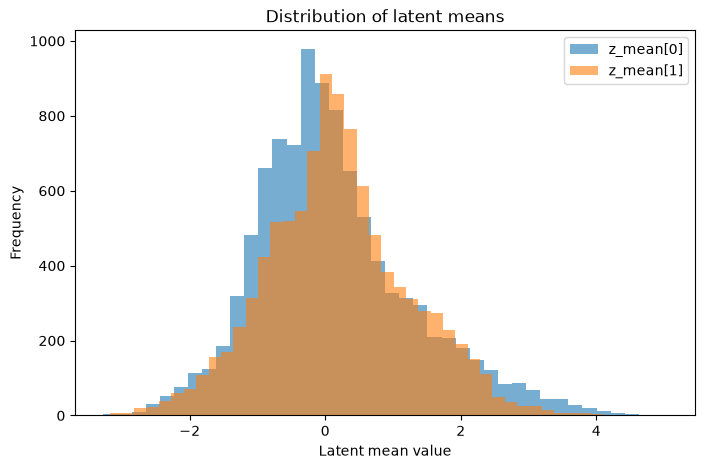

In [61]:
plt.figure(figsize=(8, 5))
plt.hist(z_mean_test[:, 0], bins=40, alpha=0.6, label='z_mean[0]')
plt.hist(z_mean_test[:, 1], bins=40, alpha=0.6, label='z_mean[1]')
plt.xlabel('Latent mean value')
plt.ylabel('Frequency')
plt.title('Distribution of latent means')
plt.legend()
plt.show()


## Generating new data

We can now use the VAE as a data generator. Instead of encoding an existing image, we sample latent vectors directly from the prior distribution, \(z \sim \mathcal{N}(0, I)\), and pass them through the decoder.

These images are synthetic: they are not copied from the training set, but generated from points in the learned latent space.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


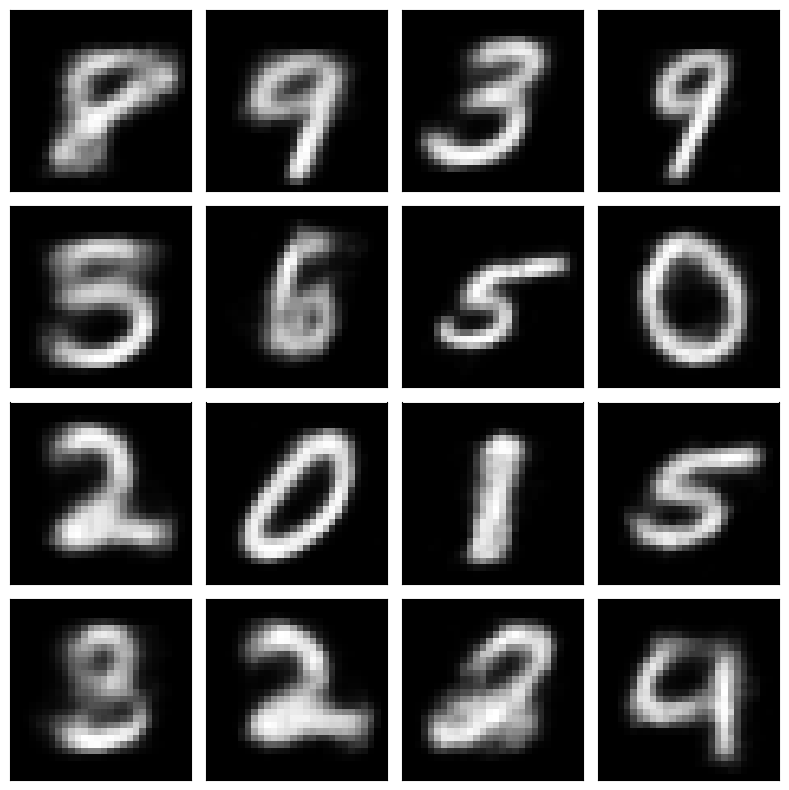

In [62]:
n_samples = 16
z_random = np.random.normal(size=(n_samples, latent_dim)).astype('float32')
generated_images = decoder.predict(z_random)

plot_generated_images(generated_images, n=n_samples)


A two-dimensional latent space also allows us to generate a grid of images. Moving horizontally or vertically across the grid changes the latent vector smoothly, so neighbouring generated images should look related.


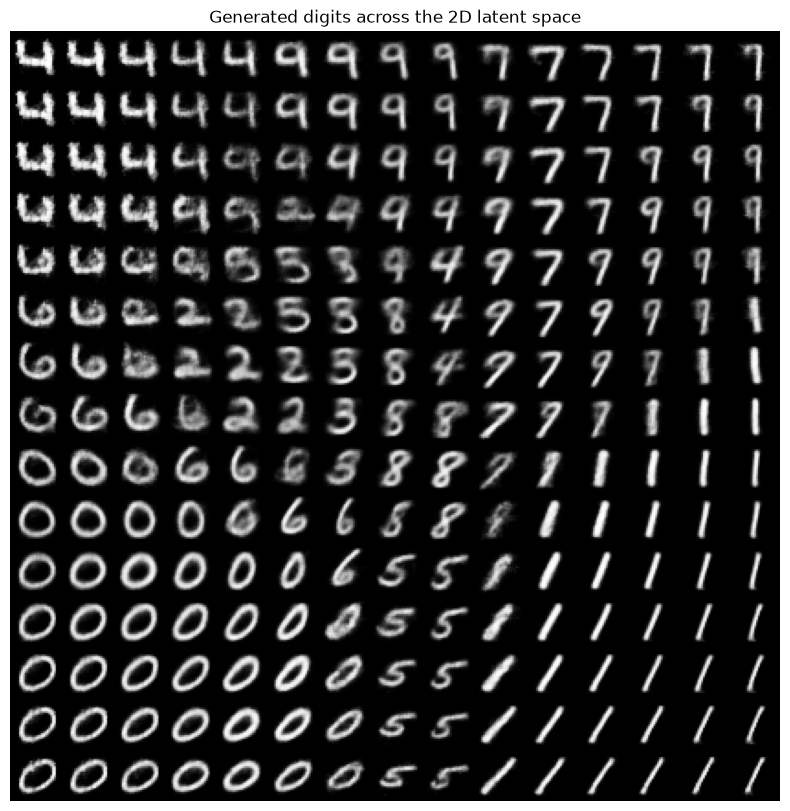

In [63]:
def plot_latent_grid(decoder, grid_size=15, scale=2.5):
    figure = np.zeros((28 * grid_size, 28 * grid_size))
    grid_x = np.linspace(-scale, scale, grid_size)
    grid_y = np.linspace(scale, -scale, grid_size)

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]], dtype='float32')
            x_decoded = decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(28, 28)
            figure[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap='gray')
    plt.axis('off')
    plt.title('Generated digits across the 2D latent space')
    plt.show()

plot_latent_grid(decoder, grid_size=15, scale=2.5)


The grid illustrates why latent-space regularisation matters. If nearby latent vectors decode to related images, then the model has learned a smoother latent representation. Without this structure, random sampling would be much more likely to fall into untrained gaps.


## Exercises

1. Compare the reconstructions from this VAE with the reconstructions from the convolutional autoencoder in `tutorial03c`. Which model gives sharper images? Why might that happen?

2. Change `latent_dim` from 2 to 8 or 16. What happens to reconstruction quality? What do you lose in terms of visualisation?

3. Increase or decrease the number of training epochs. How do the reconstruction loss and KL loss change?

4. Generate a new set of random latent vectors. Do the generated digits look plausible? Are some digits easier for the model to generate than others?

5. In your own words, explain why the KL term makes generation possible.
